In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mesa_reader import MesaData
from astropy import units as u
from astropy.constants import G
import scipy.constants as const
import os
import pickle
import sys
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "font.size": 16,             
    "axes.titlesize": 20,        
    "axes.labelsize": 18,       
    "xtick.labelsize": 16,      
    "ytick.labelsize": 16,       
    "legend.fontsize": 16,       
    "legend.title_fontsize": 18, 
    "figure.titlesize": 22       
})


In [5]:
def load_csv_fortran(filename):
    with open(filename, 'r') as f:
        header = f.readline().strip()
        col_names = header.split(',')
        lines = [line.replace('D+', 'E+').replace('D-', 'E-') for line in f.readlines()]
    data = np.genfromtxt(lines, delimiter=',')
    return col_names, data

# Planet characteristics and constants

In [9]:
Minit = np.array([0.2, 0.5, 1.0, 5.0, 10.0])  # Mj
Tinit = np.array([300, 500, 1000])  # K
ages_target = np.array([5.0])  # in Gyr. I choose the age at which I want information about the planets
z = 0.017
#core_mass = "Mcore=0.01Me_homogeneous"
core_mass = "Mcore=10Me"

# Radius vs mass plots at three ages

I summarize the radius of planets with different masses and equilibrium temperatures. In the cell below I loop over all different combinations of planet mass, temperature and core mass. I calculate the radius of the planets by interpolating the data at three different ages. I summarize this in the plot below per mass and per temperature. 

No MESA file for 0.2Mj, 300K, Mcore=10Me
No MESA file for 0.5Mj, 300K, Mcore=10Me
No MESA file for 1.0Mj, 300K, Mcore=10Me
No MESA file for 5.0Mj, 300K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Z=0.017, Mcore=10Me
No MESA file for 10.0Mj, 300K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=300 K, Z=0.017, Mcore=10Me
No MESA file for 0.2Mj, 500K, Mcore=10Me
No MESA file for 0.5Mj, 500K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=500 K, Z=0.017, Mcore=10Me
No MESA file for 10.0Mj, 500K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=500 K, Z=0.017, Mcore=10Me
No MESA file for 0.2Mj, 1000K, Mcore=10Me
No MESA file for 0.5Mj, 1000K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=1000 K, Z=0.017, Mcore=10Me
No MESA file for 10.0Mj, 1000K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=1000 K, Z=0.017, Mcore=10Me
No MESA file for 0.2Mj, 300K, Mcore=10Me
No MESA file for 0.5Mj, 300K, Mcore=10Me
No MESA file for 1.0Mj, 

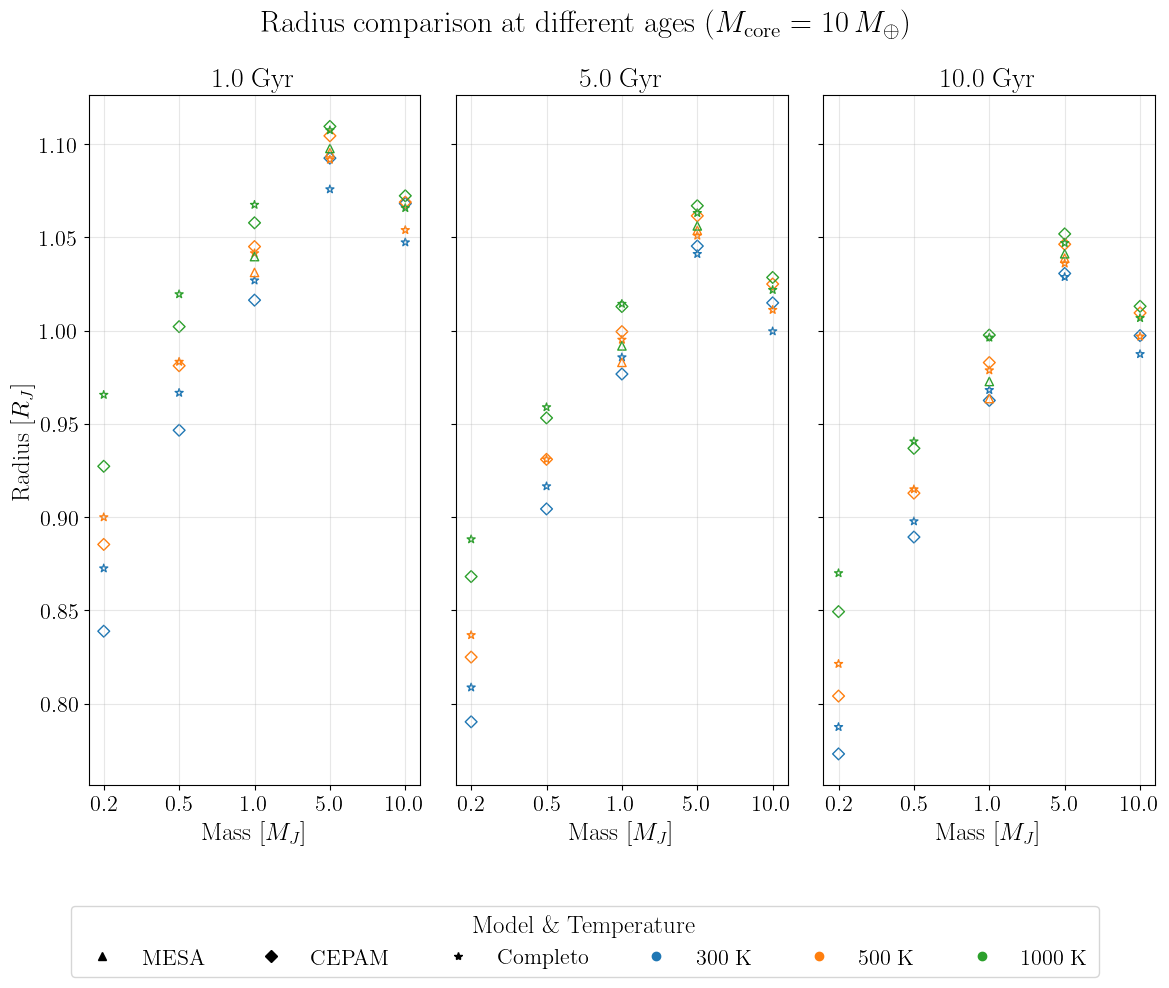

In [8]:
ages_target = np.array([1.0, 5.0, 10.0])  # Gyr

def plot_radius_vs_mass(ax, age_value, Minit, Tinit, z,
                        mass_to_x, mass_positions, colors):

    for t in Tinit:
        color = colors[t]

        for m in Minit:

############## MESA
            mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_2.0_Rj_zbar={z}_inert_core_s=11.0.history"
            try:
                mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
                age_m = mesa_data_history[:, 2]
                age_m = age_m/(10**9)
                radius_m = (mesa_data_history[:, 8] * u.R_sun).to(u.R_jup).value
                if age_value <= age_m.max():
                    radius_m_t = np.interp(age_value, age_m, radius_m)
                    if age_m.max() < 10:
                        print(f"MESA: for {m}Mj and {t}K, the planet has a maximum age of {age_m.max()}")
                else:
                    radius_m_t = None
                    print(f"Age value is higher than max age (age_value = {age_value}, max age = {age_m.max()})")
            except FileNotFoundError:
                radius_m_t = None
                print(f"No MESA file for {m}Mj, {t}K, {core_mass}")

################### CEPAM
            file_20 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_2.0Rj_{z}z_0.01s/mev_ev.csv"
            file_10 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_1.0Rj_{z}z_0.01s/mev_ev.csv"
            

            if os.path.exists(file_20):
                cepam_file_ev = file_20
            elif os.path.exists(file_10):
                cepam_file_ev = file_10
                print(f"Using fallback radius 1.0 Rj for M={m} Mj, T={t} K, Z={z}, {core_mass}")
            else:
                cepam_file_ev = None
                radius_c_t = None
                print(f"No CEPAM file found for M={m} Mj, T={t} K at 2.0Rj or 1.0Rj, {core_mass}")

            if cepam_file_ev is not None:
                col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
                age_c = cepam_data_ev[:, 0] / 1e3
                radius_c = (cepam_data_ev[:, 2] * u.cm).to(u.R_jup).value

                radius_c_t = np.interp(age_value, age_c, radius_c) \
                             if age_value <= age_c.max() else None

################ Completo
            if core_mass == "Mcore=0.01Me_homogeneous":
                mcore = 0.01
            if core_mass == "Mcore=10Me":
                mcore = 10
                
            completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
            try:
                completo_data_ev = np.loadtxt(completo_file_ev)
                age_cp = completo_data_ev[:, 1] # in years
                age_cp = age_cp / (10**9) # in Gyr
                radius_cp = completo_data_ev[:, 6] * u.R_jup
                radius_cp_t = np.interp(age_value, age_cp, radius_cp)
                radius_cp_t = radius_cp_t.value
    
            except FileNotFoundError:
                radius_cp_t = None  
                print(f"No Completo file for {m}Mj, {t}K, {core_mass}")

################# Plotting
            if radius_m_t is not None:
                ax.scatter(mass_to_x[m], radius_m_t, marker="^",
                           facecolors='none', edgecolor=color)
            if radius_c_t is not None:
                ax.scatter(mass_to_x[m], radius_c_t, marker="D",
                           facecolors='none', edgecolor=color)
            if radius_cp_t is not None:
                ax.scatter(mass_to_x[m], radius_cp_t, marker="*",
                           facecolors='none', edgecolor=color)

    # Axis formatting
    ax.set_xticks(mass_positions)
    ax.set_xticklabels(Minit)
    ax.set_title(f"{age_value} Gyr")
    ax.grid(alpha=0.3)


# Plotting
fig, axes = plt.subplots(1, len(ages_target), figsize=(12, 10), sharey=True)
if core_mass == "Mcore=0.01Me_homogeneous":
    fig.suptitle(f"Radius comparison at different ages ($M_{{\\mathrm{{core}}}} = 0.01 \\, M_{{\\oplus}}$)", fontsize=22)
if core_mass == "Mcore=10Me":
    fig.suptitle(f"Radius comparison at different ages ($M_{{\\mathrm{{core}}}} = 10 \\, M_{{\\oplus}}$)", fontsize=22)

mass_positions = np.arange(len(Minit))
mass_to_x = dict(zip(Minit, mass_positions))
colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}

for ax, age_value in zip(axes, ages_target):
    plot_radius_vs_mass(ax, age_value, Minit, Tinit, z,
                        mass_to_x, mass_positions, colors)
    ax.set_xlabel("Mass [$M_J$]")
axes[0].set_ylabel("Radius [$R_J$]")

# Shared legend
model_handles = [
    plt.Line2D([], [], marker="^", color="black", linestyle="None", label="MESA"),
    plt.Line2D([], [], marker="D", color="black", linestyle="None", label="CEPAM"),
    plt.Line2D([], [], marker="*", color="black", linestyle="None", label="Completo"),
]
temp_handles = [
    plt.Line2D([], [], marker="o", color=colors[300], linestyle="None", label="300 K"),
    plt.Line2D([], [], marker="o", color=colors[500], linestyle="None", label="500 K"),
    plt.Line2D([], [], marker="o", color=colors[1000], linestyle="None", label="1000 K"),
]

handles = model_handles + temp_handles
labels = [h.get_label() for h in handles]

fig.legend(handles, labels, title="Model \& Temperature",
           loc="lower center", ncol=6)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


# Heat plots

I want to know how much the three different codes (MESA, CEPAM, Completo) differ from each other. I visualize this in heat plots. First I write functions to make the heatplots and to calculate the (absolute) mean and standard deviation.

In [13]:
def plot_pairwise_heatmaps(pairwise, Tinit, Minit, age_value, core_mass, z):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    if core_mass == "Mcore=0.01Me_homogeneous":
        fig.suptitle(f"Radius differences at {age_value} Gyr ($M_{{\\mathrm{{core}}}} = 0.01 \\, M_{{\\oplus}}$)", fontsize=22)
    if core_mass == "Mcore=10Me":
        fig.suptitle(f"Radius differences at {age_value} Gyr ($M_{{\\mathrm{{core}}}} = 10 \\, M_{{\\oplus}}$)", fontsize=22)

    keys = ["MESA-CEPAM", "MESA-Completo", "CEPAM-Completo"]

    all_values = []
    for key in keys:
        for t in Tinit:
            for m in Minit:
                val = pairwise[key][t][m]
                if val is not None:
                    all_values.append(val)
    
    # Symmetric linear range
    abs_max = max(abs(min(all_values)), abs(max(all_values)))
    global_vmin = -abs_max
    global_vmax = abs_max
    
    norm = TwoSlopeNorm(vmin=global_vmin, vcenter=0, vmax=global_vmax)

    for ax, key in zip(axes, keys):
        mat = np.array([
            [pairwise[key][t][m] if pairwise[key][t][m] is not None else np.nan for m in Minit]
            for t in Tinit
        ])
    
        im = ax.imshow(
            mat,
            cmap="coolwarm",
            norm=norm,
            aspect="auto"
        )
    
        for i in range(len(Tinit)):
            for j in range(len(Minit)):
                val = mat[i, j]
                if not np.isnan(val):
                    ax.text(
                        j, i, f"{val:.3f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=12,
                        fontweight="bold"
                    )

        # Plotting
        ax.set_title(f"{key}")
        ax.set_xticks(range(len(Minit)))
        ax.set_xticklabels(Minit)
        ax.set_yticks(range(len(Tinit)))
        ax.set_yticklabels(Tinit)
        ax.invert_yaxis()
        ax.set_xlabel("Mass [$M_J$]")
        ax.set_ylabel("Temperature [K]")
    
        ax.set_xticks(np.arange(len(Minit)+1)-0.5, minor=True)
        ax.set_yticks(np.arange(len(Tinit)+1)-0.5, minor=True)
        ax.grid(which="minor", color="black", linewidth=0.5)
        ax.tick_params(which="minor", bottom=False, left=False)
    
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Radius difference [$R_J$]")
    
    plt.show()

def compute_pairwise_stats(pairwise, Tinit, Minit):
    stats = {}

    for key in ["MESA-CEPAM", "MESA-Completo", "CEPAM-Completo"]:
        values = []

        for t in Tinit:
            for m in Minit:
                val = pairwise[key][t][m]
                if val is not None:
                    values.append(val)

        values = np.array(values)

        stats[key] = {
            "mean_signed": np.mean(values),          
            "mean_abs": np.mean(np.abs(values)),     
            "std_signed": np.std(values),           
            "n_points": len(values)
        }

    return stats


With the functions above I can now plot the heatplots and print the statistics. I also print three tables with the mean, standard deviation and average absolute difference, as well as the same summary table I printed before. 

No MESA file for 0.2Mj, 300K, Mcore=10Me
No MESA file for 0.5Mj, 300K, Mcore=10Me
No MESA file for 1.0Mj, 300K, Mcore=10Me
No MESA file for 5.0Mj, 300K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Mcore=10Me
No MESA file for 10.0Mj, 300K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=300 K, Mcore=10Me
No MESA file for 0.2Mj, 500K, Mcore=10Me
No MESA file for 0.5Mj, 500K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=500 K, Mcore=10Me
No MESA file for 10.0Mj, 500K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=500 K, Mcore=10Me
No MESA file for 0.2Mj, 1000K, Mcore=10Me
No MESA file for 0.5Mj, 1000K, Mcore=10Me
Using fallback radius 1.0 Rj for M=5.0 Mj, T=1000 K, Mcore=10Me
No MESA file for 10.0Mj, 1000K, Mcore=10Me
Using fallback radius 1.0 Rj for M=10.0 Mj, T=1000 K, Mcore=10Me


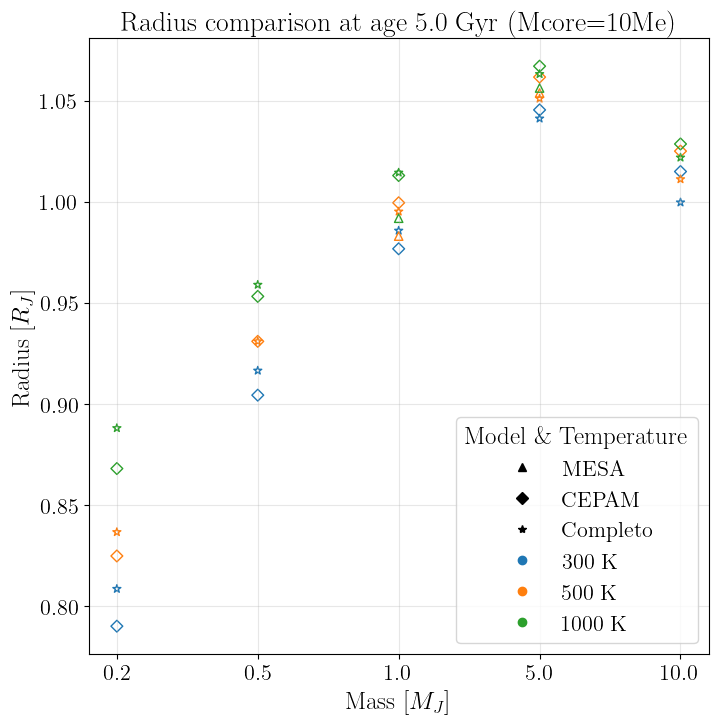

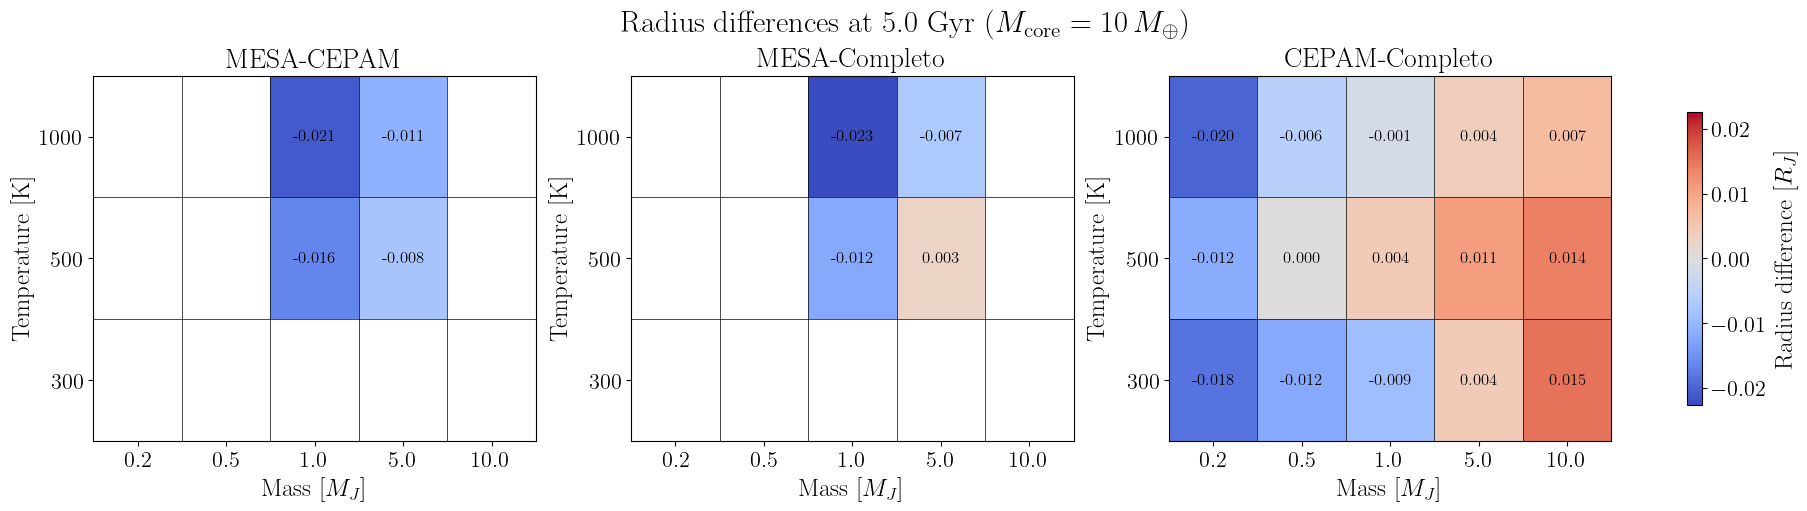


=== Average Absolute Differences at Age 5.0 Gyr ===

Temp/Mass          0.2       0.5       1.0       5.0      10.0     Row Avg
--------------------------------------------------------------------------
300 K           0.0184    0.0121    0.0090    0.0043    0.0153      0.0118
500 K           0.0118    0.0000    0.0110    0.0071    0.0139      0.0088
1000 K          0.0200    0.0057    0.0150    0.0072    0.0067      0.0109
--------------------------------------------------------------------------
Col Avg         0.0167    0.0060    0.0117    0.0062    0.0119      0.0105

=== Standard Deviation of Radii at Age 5.0 Gyr ===

Temp/Mass          0.2       0.5       1.0       5.0      10.0     Row Avg
--------------------------------------------------------------------------
300 K           0.0092    0.0061    0.0045    0.0021    0.0076      0.0059
500 K           0.0059    0.0000    0.0070    0.0045    0.0069      0.0049
1000 K          0.0100    0.0029    0.0103    0.0045    0.0034      

In [14]:
ages_target = np.array([5.0])  # Gyr
pairwise_signed = {}
radii_table = {}

for age_value in ages_target:
    # Plotting
    mass_positions = np.arange(len(Minit))
    mass_to_x = dict(zip(Minit, mass_positions))
    colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}
    plt.figure(figsize=(8,8))
    plt.xlabel("Mass [$M_J$]")
    plt.ylabel("Radius [$R_J$]")
    plt.title(f"Radius comparison at age {age_value} Gyr ({core_mass}) ")
    plt.grid(alpha=0.3)

    # Table
    table = {t: {} for t in Tinit} 
    std_table = {}
    avg_radius_table = {}
    combined = {}
    radii_table[age_value] = {t: {} for t in Tinit}

    pairwise_signed[age_value] = {
        "MESA-CEPAM": {t: {} for t in Tinit},
        "MESA-Completo": {t: {} for t in Tinit},
        "CEPAM-Completo": {t: {} for t in Tinit}
    }


    for t in Tinit:
        color = colors[t]
        std_table[t] = {}
        avg_radius_table[t] = {}
        combined[t] = {}
        
        for m in Minit:
############## MESA
            mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_2.0_Rj_zbar={z}_inert_core_s=11.0.history"
            try:
                mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
                age_m = mesa_data_history[:, 2]
                age_m = age_m/(10**9)
                radius_m = (mesa_data_history[:, 8] * u.R_sun).to(u.R_jup).value
                if age_value <= age_m.max():
                    radius_m_t = np.interp(age_value, age_m, radius_m)
                    if age_m.max() < 10:
                        print(f"MESA: for {m}Mj and {t}K, the planet has a maximum age of {age_m.max()}")
                else:
                    radius_m_t = None
                    print(f"Age value is higher than max age (age_value = {age_value}, max age = {age_m.max()})")
            except FileNotFoundError:
                radius_m_t = None
                print(f"No MESA file for {m}Mj, {t}K, {core_mass}")
    

############### CEPAM
            file_20 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_2.0Rj_{z}z_0.01s/mev_ev.csv"
            file_10 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_1.0Rj_{z}z_0.01s/mev_ev.csv"
            
            cepam_file_ev = None
            
            # Check 2.0 Rj
            if os.path.exists(file_20):
                cepam_file_ev = file_20
            else:
                # Fallback to 1.0 Rj
                if os.path.exists(file_10):
                    cepam_file_ev = file_10
                    print(f"Using fallback radius 1.0 Rj for M={m} Mj, T={t} K, {core_mass}")
                else:
                    print(f"No CEPAM file found for M={m} Mj, T={t} K at 2.0Rj or 1.0Rj, {core_mass}")
                    radius_c_t = None

            if cepam_file_ev is not None:
                col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
            
                age_c = cepam_data_ev[:,0] / 1e3  # Myr → Gyr
                radius_c = (cepam_data_ev[:,2] * u.cm).to(u.R_jup).value
            
                if age_value <= age_c.max():
                    radius_c_t = np.interp(age_value, age_c, radius_c)
                else:
                    radius_c_t = None

                    
        
################## Completo
            if core_mass == "Mcore=0.01Me_homogeneous":
                mcore = 0.01
            if core_mass == "Mcore=10Me":
                mcore = 10
                
            completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
            try:
                completo_data_ev = np.loadtxt(completo_file_ev)
                age_cp = completo_data_ev[:, 1] # in years
                age_cp = age_cp / (10**9) # in Gyr
                radius_cp = completo_data_ev[:, 6] * u.R_jup
                #radius_cp = (completo_data_ev[:, 70] * u.R_earth).to(u.R_jup) 
                radius_cp_t = np.interp(age_value, age_cp, radius_cp)
                radius_cp_t = radius_cp_t.value
    
            except FileNotFoundError:
                radius_cp_t = None    
                print(f"No Completo file for {m}Mj, {t}K, {core_mass}")

############## Absolute average differences
            radii = {"MESA": radius_m_t, "CEPAM": radius_c_t, "Completo": radius_cp_t}

            radii_table[age_value][t][m] = radii
            
            abs_diffs = {}
            if radii["Completo"] is not None and radii["CEPAM"] is not None:
                abs_diffs["|Completo - CEPAM|"] = abs(radii["Completo"] - radii["CEPAM"])
            if radii["Completo"] is not None and radii["MESA"] is not None:
                abs_diffs["|Completo - MESA|"] = abs(radii["Completo"] - radii["MESA"])
            if radii["MESA"] is not None and radii["CEPAM"] is not None:
                abs_diffs["|MESA - CEPAM|"] = abs(radii["MESA"] - radii["CEPAM"])

            if len(abs_diffs) > 0:
                avg_abs_diff = sum(abs_diffs.values()) / len(abs_diffs)
            else:
                avg_abs_diff = None

            if avg_abs_diff is not None:
                table[t][m] = avg_abs_diff
            else:
                table[t][m] = None

            
################ Standard deviation of the radii
            vals = [r for r in radii.values() if r is not None]
            
            if len(vals) > 1:
                std_radius = np.std(vals)
            else:
                std_radius = None

            if t not in std_table:
                std_table[t] = {}
            
            std_table[t][m] = std_radius


################# Average radii
            vals = [r for r in radii.values() if r is not None]
            if vals:
                avg_radius = sum(vals) / len(vals)
            else:
                avg_radius = None
            avg_radius_table[t][m] = avg_radius

            mean_val = avg_radius_table[t][m]
            std_val = std_table[t][m]
            
################## Fractional uncertainty MU
            if mean_val is not None and std_val is not None and mean_val != 0:
                frac_val = std_val / mean_val
            else:
                frac_val = None
            
#################### Combined table
            combined[t][m] = {
                "mean": mean_val,
                "std": std_val,
                "abs": table[t][m],
                "frac": frac_val
            }

            mesa = radii["MESA"]
            cepam = radii["CEPAM"]
            comp = radii["Completo"]

            pairwise_signed[age_value]["MESA-CEPAM"][t][m] = (
                mesa - cepam if mesa is not None and cepam is not None else None
            )
            pairwise_signed[age_value]["MESA-Completo"][t][m] = (
                mesa - comp if mesa is not None and comp is not None else None
            )
            pairwise_signed[age_value]["CEPAM-Completo"][t][m] = (
                cepam - comp if cepam is not None and comp is not None else None
            )

            # Plotting
            if radius_m_t is not None:
                plt.scatter(mass_to_x[m], radius_m_t,  marker="^", facecolors='none', edgecolor=color)
            if radius_c_t is not None:
                plt.scatter(mass_to_x[m], radius_c_t, marker="D", facecolors='none', edgecolor=color)
            if radius_cp_t is not None:
                plt.scatter(mass_to_x[m], radius_cp_t,  marker="*", facecolors='none', edgecolor=color)


    # Plot
    plt.scatter([], [], marker="^", label="MESA")
    plt.scatter([], [], marker="D", label="CEPAM")
    plt.scatter([], [], marker="*", label="Completo")
    plt.xticks(mass_positions, Minit)
    
    model_handles = [
        plt.Line2D([], [], marker="^", color="black", linestyle="None", label="MESA"),
        plt.Line2D([], [], marker="D", color="black", linestyle="None", label="CEPAM"),
        plt.Line2D([], [], marker="*", color="black", linestyle="None", label="Completo"),
    ]
    temp_handles = [
        plt.Line2D([], [], marker="o", color=colors[300], linestyle="None", label="300 K"),
        plt.Line2D([], [], marker="o", color=colors[500], linestyle="None", label="500 K"),
        plt.Line2D([], [], marker="o", color=colors[1000], linestyle="None", label="1000 K"),
    ]
    all_handles = model_handles + temp_handles
    plt.legend(handles=all_handles, title="Model \& Temperature", loc="lower right")
    plt.show()

    plot_pairwise_heatmaps(pairwise_signed[age_value], Tinit, Minit, age_value, core_mass, z)
    stats = compute_pairwise_stats(pairwise_signed[age_value], Tinit, Minit)

##### Tables
    # Table with average absolute differences
    row_avgs = {}
    for t in Tinit:
        vals = [table[t][m] for m in Minit if table[t][m] is not None]
        row_avgs[t] = sum(vals) / len(vals) if vals else None
    col_avgs = {}
    for m in Minit:
        vals = [table[t][m] for t in Tinit if table[t][m] is not None]
        col_avgs[m] = sum(vals) / len(vals) if vals else None
    all_vals = [
        table[t][m]
        for t in Tinit
        for m in Minit
        if table[t][m] is not None
    ]
    
    grand_avg = sum(all_vals) / len(all_vals) if all_vals else None

    print(f"\n=== Average Absolute Differences at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = table[t][m]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs[t]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs[m]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg:>12.4f}" if grand_avg is not None else f"{'N/A':>12}"
    print(row)

    
    # Table with standard deviations
    row_avgs_std = {}
    for t in Tinit:
        vals = [std_table[t][m] for m in Minit if std_table[t][m] is not None]
        row_avgs_std[t] = sum(vals)/len(vals) if vals else None
    
    col_avgs_std = {}
    for m in Minit:
        vals = [std_table[t][m] for t in Tinit if std_table[t][m] is not None]
        col_avgs_std[m] = sum(vals)/len(vals) if vals else None
    
    all_vals = [
        std_table[t][m]
        for t in Tinit
        for m in Minit
        if std_table[t][m] is not None
    ]
    grand_avg_std = sum(all_vals)/len(all_vals) if all_vals else None

    print(f"\n=== Standard Deviation of Radii at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = std_table[t][m]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs_std[t]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs_std[m]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg_std:>12.4f}" if grand_avg_std is not None else f"{'N/A':>12}"
    print(row)

    
    # Table average radii
    row_avgs_R = {}
    for t in Tinit:
        vals = [avg_radius_table[t][m] for m in Minit if avg_radius_table[t][m] is not None]
        row_avgs_R[t] = sum(vals)/len(vals) if vals else None
    
    col_avgs_R = {}
    for m in Minit:
        vals = [avg_radius_table[t][m] for t in Tinit if avg_radius_table[t][m] is not None]
        col_avgs_R[m] = sum(vals)/len(vals) if vals else None
    
    all_vals = [
        avg_radius_table[t][m]
        for t in Tinit
        for m in Minit
        if avg_radius_table[t][m] is not None
    ]
    grand_avg_R = sum(all_vals)/len(all_vals) if all_vals else None

    print(f"\n=== Average Radius at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = avg_radius_table[t][m]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs_R[t]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs_R[m]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg_R:>12.4f}" if grand_avg_R is not None else f"{'N/A':>12}"
    print(row)

    
    # Combined summary table
    metrics = ["mean", "std", "frac", "abs"]
    
    # Row averages
    row_avg = {t: {} for t in Tinit}
    for t in Tinit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for m in Minit
                if combined[t][m][metric] is not None
            ]
            row_avg[t][metric] = sum(vals)/len(vals) if vals else None
    
    # Column averages
    col_avg = {m: {} for m in Minit}
    for m in Minit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for t in Tinit
                if combined[t][m][metric] is not None
            ]
            col_avg[m][metric] = sum(vals)/len(vals) if vals else None
    
    # Grand averages
    grand_avg = {}
    for metric in metrics:
        vals = [
            combined[t][m][metric]
            for t in Tinit
            for m in Minit
            if combined[t][m][metric] is not None
        ]
        grand_avg[metric] = sum(vals)/len(vals) if vals else None
    
    
    print(f"\n=== Combined Radius Metrics at Age {age_value} Gyr ===\n")
    
    
    header = "Temp/Mass".ljust(12) + "Metric".ljust(10)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    
    
    for t in Tinit:
    
        # mean row
        row = f"{t} K".ljust(12) + "mean".ljust(10)
        for m in Minit:
            val = combined[t][m]["mean"]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["mean"]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # std row
        row = " ".ljust(12) + "std".ljust(10)
        for m in Minit:
            val = combined[t][m]["std"]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["std"]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # MU row
        row = " ".ljust(12) + "frac".ljust(10)
        for m in Minit:
            val = combined[t][m]["frac"]
            row += f"{val*100:>10.2f}%" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["frac"]
        row += f"{ravg*100:>12.2f}%" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # abs row
        row = " ".ljust(12) + "abs".ljust(10)
        for m in Minit:
            val = combined[t][m]["abs"]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["abs"]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        print()  
    
    
    print("-" * len(header))
    
    # mean column
    row = "Col Avg".ljust(12) + "mean".ljust(10)
    for m in Minit:
        val = col_avg[m]["mean"]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['mean']:>12.4f}"
    print(row)
    
    # std column
    row = " ".ljust(12) + "std".ljust(10)
    for m in Minit:
        val = col_avg[m]["std"]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['std']:>12.4f}"
    print(row)
    
    # MU column
    row = " ".ljust(12) + "frac".ljust(10)
    for m in Minit:
        val = col_avg[m]["frac"]
        row += f"{val*100:>10.2f}%" if val is not None else f"{'N/A':>10}"
    gavg = grand_avg["frac"]
    row += f"{gavg*100:>12.2f}%" if gavg is not None else f"{'N/A':>12}"
    print(row)
    
    # abs column
    row = " ".ljust(12) + "abs".ljust(10)
    for m in Minit:
        val = col_avg[m]["abs"]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['abs']:>12.4f}"
    print(row)


######### Print pairwise statistics 
    print(f"\n=== Pairwise Statistics for age = {age_value} Gyr ===\n")

    for key, s in stats.items():
        print(f"{key}:")
        print(f"  Mean signed difference : {s['mean_signed']:.4f}")
        print(f"  Mean absolute diff     : {s['mean_abs']:.4f}")
        print(f"  Std of signed diff     : {s['std_signed']:.4f}")
        print(f"  Number of points       : {s['n_points']}")
        print()

